# Hydrogen Atom: 
## Radial Wavefunctions and Associated Laguerre Polynomials
In this exercise, we study the quantum mechanical hydrogen atom, focusing on the radial part of its wavefunction. The hydrogen atom is one of the few systems in quantum mechanics that can be solved analytically, and its solutions provide deep insight into the structure of atomic orbitals.

To begin, we import the necessary scientific computing libraries and define the physical constants (`a0 = 1`) that will be used throughout this exercise. These tools allow us to perform numerical calculations, evaluate special functions such as the associated Laguerre polynomials, and visualize the resulting hydrogen radial wavefunctions. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import eval_genlaguerre

a0 = 1

Next, define a helper function `assoc_laguerre(k, alpha, x)` to evaluate the associated (generalized) Laguerre polynomials $(L_k^{(\alpha)}(x)$ ).  
Hint: Instead of implementing the recursion manually, you can use SciPy’s built-in routine `eval_genlaguerre`, which is efficient and numerically stable.


In [10]:
def assoc_laguerre(k, alpha, x):
    return eval_genlaguerre(k, alpha, x)

In [11]:
x_test = np.array([0.0, 1.0, 2.0])
assert callable(assoc_laguerre), "assoc_laguerre must be a callable function"
assert np.allclose(assoc_laguerre(0, 0, x_test), np.ones_like(x_test)), \
    "L_0^(0)(x) should be 1"
assert np.allclose(assoc_laguerre(1, 0, x_test), 1 - x_test), \
    "L_1^(0)(x) should equal 1 - x"
assert np.allclose(assoc_laguerre(1, 1, x_test), 2 - x_test), \
    "L_1^(1)(x) should equal 2 - x"

Now implement the hydrogen atom radial wavefunction $(R_{nl}(r))$.  
First convert the radius array $(r)$ into the dimensionless variable $(\rho = \frac{2r}{n a_0})$, then compute the polynomial order $(k=n-l-1)$ and parameter $(\alpha=2l+1)$.  
Finally, combine the exponential factor, the power-law term, the associated Laguerre polynomial, and the normalization constant so that the wavefunction satisfies  
$(\int_0^\infty |R_{nl}(r)|^2 r^2 \, dr = 1)$.

The Wavefunktion is then given by:

$[
R_{nl}(r) =
\sqrt{\left(\frac{2}{n a_0}\right)^3
\frac{(n-l-1)!}{2n (n+l)!}}
\;
e^{-\rho/2}
\;
\rho^{\,l}
\;
L_{n-l-1}^{(2l+1)}(\rho),
\quad
\text{with}
\quad
\rho = \frac{2r}{n a_0}.
]$

At the End you should get a funktion that looks like this `R_nl(r: np.ndarray, n: int, l: int, a0: float = 1.0) -> np.ndarray` and retourns an array that represents the normalized radial wavefunktion 


In [26]:
from scipy.special import factorial

def R_nl(r: np.ndarray, n: int, l: int, a0: float = 1.0) -> np.ndarray:
    r = np.asarray(r, dtype=float)
    if n < 1 or l < 0 or l > n - 1:
        raise ValueError("n>=1 and 0<=l<=n-1 needed")

    sqrt_raw = np.pow(2 / (n * a0), 3) * (factorial(n-l-1))/(2*n*factorial(n+l))
    rho = (2*r)/(n*a0)

    return np.sqrt(sqrt_raw) * np.exp(-rho/2) * np.pow(rho, l) * assoc_laguerre(n-l-1, 2*l + 1, rho)

In [27]:
r_test = np.linspace(0.0, 40.0, 4000)
R_10 = R_nl(r_test, 1, 0, a0)
R_21 = R_nl(r_test, 2, 1, a0)

assert isinstance(R_10, np.ndarray), "R_nl must return a NumPy array"
assert R_10.shape == r_test.shape, "R_nl must return an array with the same shape as r"
assert np.isfinite(R_10).all(), "R_nl returned non-finite values"
assert np.isclose(R_nl(np.array([0.0]), 1, 0, a0)[0], 2.0, rtol=1e-6), \
    "For a0=1, R_10(0) should be 2"
assert np.isclose(R_nl(np.array([0.0]), 2, 1, a0)[0], 0.0, atol=1e-12), \
    "For l>0, R_nl(0) should be 0"

Now compute the radial probability density.

Square the absolute value of the radial wavefunction and multiply by $r^2$.  
The radial probability density is defined as

$
P(r) = r^2 \, |R_{nl}(r)|^2.
$

This quantity represents the probability of finding the electron in the spherical shell between $r$ and $r + dr$.  

Implement a function that takes $r$ and $R_{nl}(r)$ as input and returns $P(r)$. `radial_probability(r: np.ndarray, R: np.ndarray) -> np.ndarray:`

In [44]:
def radial_probability(r: np.ndarray, R: np.ndarray) -> np.ndarray:
    return np.square(r) * np.square(np.abs(R))

In [45]:
r_test = np.array([0.0, 1.0, 2.0])
R_test = np.array([1.0, -2.0, 1j])
P_test = radial_probability(r_test, R_test)
expected_P = np.array([0.0, 4.0, 4.0])

assert isinstance(P_test, np.ndarray), "radial_probability must return a NumPy array"
assert P_test.shape == r_test.shape, "radial_probability must preserve the input shape"
assert np.allclose(P_test, expected_P), \
    "radial_probability must compute r^2 * |R|^2"
assert np.all(P_test >= 0), "radial_probability must never return negative values"

Run the following code cell to compute and plot the radial probability density $P(r)$ for a chosen pair of quantum numbers $(n,l)$.

If everything is implemented correctly, you should see a curve for $P(r)$ as a function of $r$.


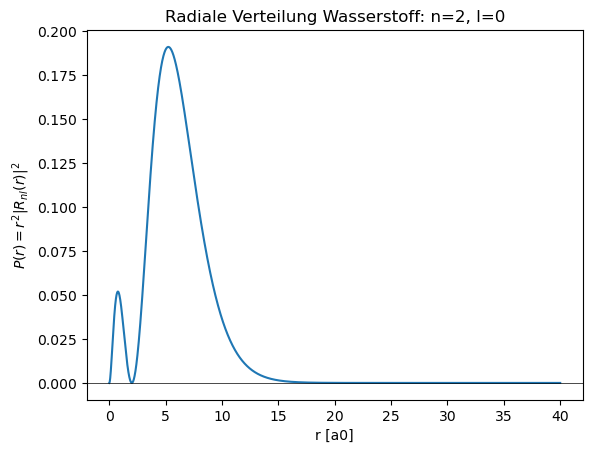

In [46]:
n, l = 2, 0      # 1s: (1,0), 2s: (2,0), 2p: (2,1), 3d: (3,2)
r = np.linspace(0.0, 40.0, 3000)

R = R_nl(r, n, l, a0)
P = radial_probability(r, R)

plt.plot(r, P)
plt.xlabel("r [a0]")
plt.ylabel(r"$P(r)=r^2 |R_{nl}(r)|^2$")
plt.title(f"Radiale Verteilung Wasserstoff: n={n}, l={l}")
plt.axhline(0, color = "black", lw = 0.5)
#plt.xlim(0, 40)
plt.show()

Use the radial probability density $P(r)=r^2 |R_{nl}(r)|^2$ to compute the probability of finding the electron
between two radii $r_1$ and $r_2$.

The probability in the interval $[r_1,r_2]$ is obtained by integrating:

$
\Pr(r_1 \le r \le r_2) = \int_{r_1}^{r_2} P(r)\,dr.
$

Implement a function that takes the arrays $r$ and $P(r)$ and returns the numerical value of this integral.
Then test it for a chosen interval and state $(n,l)$.

**Hint:** To approximate the integral numerically on a discrete grid, use the **trapezoidal rule** (Trapezregel) by summing up the areas of small trapezoids between neighboring grid points.

In [77]:
def radial_probability_density(r: np.ndarray, P: np.ndarray, r1: int, r2: int):
    prob = 0.0
    for i in range(r1, r2):
        dr = r[i+1] - r[i]
        prob += 0.5 * (P[i] + P[i+1]) * dr
    return float(prob)

prob = radial_probability_density(r, P, 0, len(r)-1)
print(prob)

0.9999999997349235


In [78]:
assert 0.0 <= prob <= 1.0 + 1e-3, "A probability should be between 0 and 1"
assert math.isclose(prob, 0.9999580974907748, abs_tol=0.1)

NameError: name 'math' is not defined

# Spherical Harmonics

These are the angular-dependent parts of the corresponding wave function in a hydrogen atom. It can generally be denoted with this formula:

$$
Y_l^m(\theta,\phi)
=
(-1)^m
\sqrt{
\frac{2l+1}{4\pi}
\frac{(l-m)!}{(l+m)!}
}
P_l^m(\cos\theta)
e^{i m \phi}
$$

The following part is a demonstration on how to plot the real part of the spherical harmonics.

In [56]:
from scipy.special import sph_harm

def real_sph_harm(l, m, theta, phi):
    """
    Real spherical harmonics built from SciPy's complex sph_harm.
    theta: polar angle in [0, pi]
    phi: azimuth in [0, 2pi]
    """
    if m == 0:
        return sph_harm(0, l, phi, theta).real

    Y = sph_harm(abs(m), l, phi, theta)  # complex Y_l^{|m|}
    phase = (-1)**abs(m)

    if m > 0:
        return np.sqrt(2) * phase * Y.real
    else:
        return np.sqrt(2) * phase * Y.imag

In [57]:
def plot_real_Ylm(l, m, radius_mode="abs", n_theta=200, n_phi=400):
    theta = np.linspace(0, np.pi, n_theta)
    phi   = np.linspace(0, 2*np.pi, n_phi)
    theta, phi = np.meshgrid(theta, phi, indexing="ij")

    Y = real_sph_harm(l, m, theta, phi)

    if radius_mode == "abs":
        R = np.abs(Y)
    elif radius_mode == "abs2":
        R = Y**2   # (since Y is real here, abs^2 = Y^2)
    else:
        raise ValueError("radius_mode must be 'abs' or 'abs2'")

    # avoid a totally flat radius (optional, makes shapes clearer)
    R = R / (R.max() + 1e-12)

    # spherical -> cartesian
    x = R * np.sin(theta) * np.cos(phi)
    y = R * np.sin(theta) * np.sin(phi)
    z = R * np.cos(theta)

    # color by value (sign/strength)
    C = (Y - Y.min()) / (Y.max() - Y.min() + 1e-12)

    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(
        x, y, z,
        facecolors=plt.cm.jet(C),   # similar “rainbow” look
        rstride=2, cstride=2,
        linewidth=0, antialiased=True, shade=False
    )

    ax.set_title(rf"real $Y_{{{l}}}^{{{m}}}$  (radius = {radius_mode})")
    ax.set_axis_off()
    ax.set_box_aspect([1, 1, 1])
    plt.show()

/tmp/ipykernel_290/416998964.py:10: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  return sph_harm(0, l, phi, theta).real


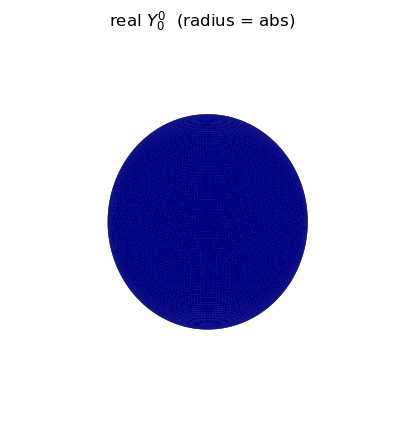

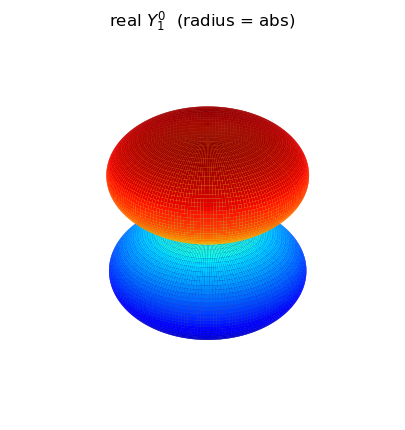

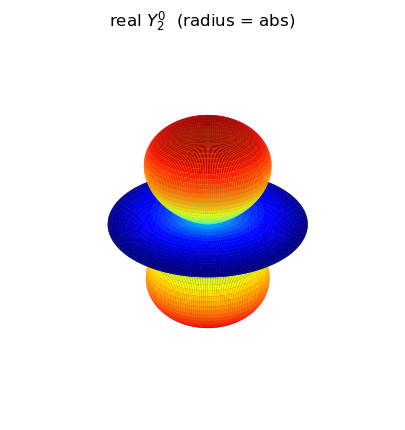

/tmp/ipykernel_290/416998964.py:12: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  Y = sph_harm(abs(m), l, phi, theta)  # complex Y_l^{|m|}


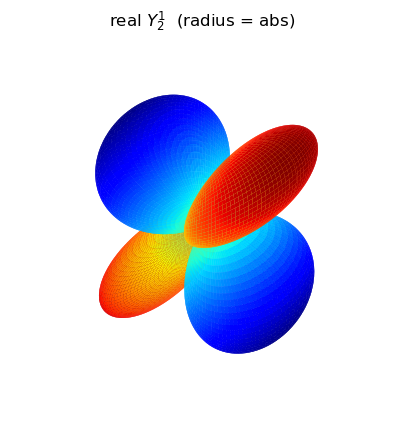

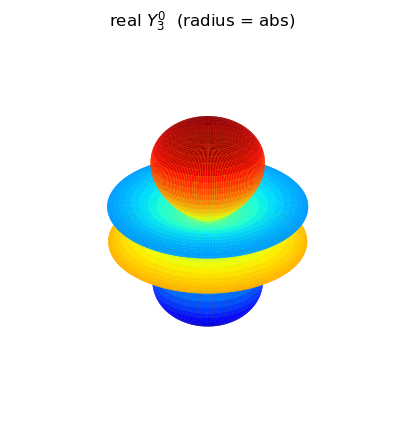

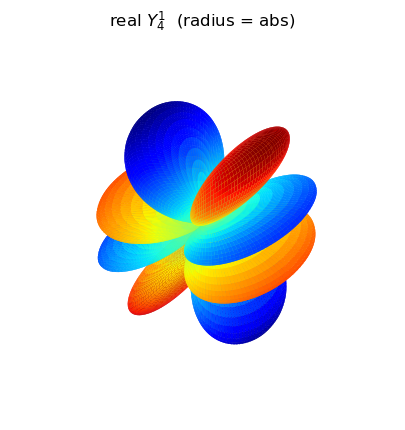

In [58]:
for (l, m) in [(0,0), (1,0), (2,0), (2,1), (3,0), (4,1)]:
    plot_real_Ylm(l, m, radius_mode="abs")